# Netflix Movie Recommendation System
## Hybrid: Knowledge-Based + Reinforcement Learning
### Based on Kaggle Netflix Prize Dataset


# **SECTION 1: SETUP AND IMPORTS**


In [54]:
import subprocess
import sys

packages = ['kagglehub', 'scikit-learn', 'pandas', 'numpy', 'scipy', 'gym', 'matplotlib', 'seaborn']

for package in packages:
    try:
        __import__(package)
        print(f'✅ {package} is already installed')
    except ImportError:
        print(f'📦 Installing {package}...')
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f'✅ {package} installed')

print('\n' + '='*70)
print('All required packages are ready!')
print('='*70)

✅ kagglehub is already installed
📦 Installing scikit-learn...
✅ scikit-learn installed
✅ pandas is already installed
✅ numpy is already installed
✅ scipy is already installed
✅ gym is already installed
✅ matplotlib is already installed
✅ seaborn is already installed

All required packages are ready!


In [55]:
# Core imports
import csv
import json
import numpy as np
import pandas as pd
import scipy.sparse as sp
import sklearn.metrics as skm
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import gym
from gym import spaces
import kagglehub
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ All imports successful!')

✅ All imports successful!


---
## SECTION 2: NETFLIX DATASET LOADING
---

In [56]:
# Download Netflix dataset
print('📥 Downloading Netflix dataset from Kaggle...')
print('   (This may take a moment on first run)\n')

try:
    path = kagglehub.dataset_download('shivamb/netflix-shows')
    print(f'✅ Dataset downloaded successfully!')
    print(f'📁 Path: {path}')
    dataset_available = True
except Exception as e:
    print(f'Note: {e}')
    print('\n💡 We will create a sample Netflix dataset for demonstration')
    dataset_available = False
    path = None

📥 Downloading Netflix dataset from Kaggle...
   (This may take a moment on first run)

Using Colab cache for faster access to the 'netflix-shows' dataset.
✅ Dataset downloaded successfully!
📁 Path: /kaggle/input/netflix-shows


In [57]:
import os

if dataset_available and path:
    print('\n📂 Files in dataset:')
    files_list = os.listdir(path)
    for file in files_list:
        file_path = os.path.join(path, file)
        file_size = os.path.getsize(file_path) / (1024*1024)
        print(f'   - {file} ({file_size:.2f} MB)')

    csv_files = [f for f in files_list if f.endswith('.csv')]
    print(f'\n✅ Found {len(csv_files)} CSV file(s)')
else:
    print('Creating sample Netflix dataset...')


📂 Files in dataset:
   - netflix_titles.csv (3.24 MB)

✅ Found 1 CSV file(s)


In [58]:
# Load the Netflix dataset
if dataset_available and path:
    csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
    netflix_path = os.path.join(path, csv_file)
    netflix_df = pd.read_csv(netflix_path)
else:
    # Create realistic sample Netflix dataset
    np.random.seed(42)
    n_movies = 300

    movie_titles = [
        'Inception', 'The Dark Knight', 'Interstellar', 'Avatar', 'Titanic',
        'The Matrix', 'Pulp Fiction', 'Forrest Gump', 'The Shawshank Redemption',
        'The Godfather', 'Fight Club', 'Gladiator', 'The Avengers', 'Iron Man',
        'Captain America', 'Thor', 'Black Panther', 'Spider-Man', 'The Lion King',
        'Frozen', 'Toy Story', 'Monsters Inc', 'Finding Nemo', 'The Incredibles'
    ]

    netflix_df = pd.DataFrame({
        'show_id': [f's{i}' for i in range(n_movies)],
        'title': [f'{movie_titles[i % len(movie_titles)]} {i//len(movie_titles)}' for i in range(n_movies)],
        'type': np.random.choice(['Movie', 'TV Show'], n_movies, p=[0.7, 0.3]),
        'kaggle kernels output muhammadhananasghar/imdb-movies-content-based-recomendation-system -p /path/to/dest': np.random.choice(['G', 'PG', 'PG-13', 'R'], n_movies),
        'listed_in': [', '.join(np.random.choice(['Drama', 'Comedy', 'Action', 'Romance', 'Thriller', 'Sci-Fi'], 2)) for _ in range(n_movies)]
    })

print(f'✅ Dataset loaded!')
print(f'\nDataset Shape: {netflix_df.shape}')
print(f'\nFirst few rows:')
print(netflix_df.head())

✅ Dataset loaded!

Dataset Shape: (8807, 12)

First few rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021   

In [59]:
# Create user ratings
print('📊 Creating user ratings data...\n')

np.random.seed(42)
n_users = 200
n_ratings = 3000

ratings_data = []
for _ in range(n_ratings):
    user_id = np.random.randint(1, n_users + 1)
    movie_idx = np.random.randint(0, len(netflix_df))
    movie_id = netflix_df.iloc[movie_idx]['show_id']
    rating = np.random.choice([1, 2, 3, 4, 5], p=[0.05, 0.1, 0.2, 0.35, 0.3])

    ratings_data.append({
        'userId': user_id,
        'movieId': movie_id,
        'rating': rating
    })

ratings_df = pd.DataFrame(ratings_data)
ratings_df = ratings_df.drop_duplicates(subset=['userId', 'movieId'], keep='last')

print(f'✅ Ratings created!')
print(f'\nRatings Shape: {ratings_df.shape}')
print(f'Unique Users: {ratings_df['userId'].nunique()}')
print(f'Unique Movies: {ratings_df['movieId'].nunique()}')

📊 Creating user ratings data...

✅ Ratings created!

Ratings Shape: (2996, 3)
Unique Users: 200
Unique Movies: 2505


In [60]:
import pandas as pd

# Merge datasets
print('🔗 Merging ratings with movie information...\n')

combined_df = pd.merge(ratings_df, netflix_df, left_on='movieId', right_on='show_id', how='inner')

# Clean data
combined_df = combined_df.dropna(subset=['userId', 'movieId', 'rating_x'])
combined_df['rating_x'] = pd.to_numeric(combined_df['rating_x'], errors='coerce')
combined_df = combined_df.dropna(subset=['rating_x'])

# Filter users with at least 3 ratings
user_counts = combined_df['userId'].value_counts()
active_users = user_counts[user_counts >= 3].index
combined_df = combined_df[combined_df['userId'].isin(active_users)]

print(f'✅ Data prepared!')
print(f'\nDataset Shape: {combined_df.shape}')
print(f'Users: {combined_df['userId'].nunique()}')
print(f'Movies: {combined_df['movieId'].nunique()}')

🔗 Merging ratings with movie information...

✅ Data prepared!

Dataset Shape: (2996, 15)
Users: 200
Movies: 2505


In [61]:
display(combined_df.head())

,userId,movieId,rating_x,show_id,type,title,director,cast,country,date_added,release_year,rating_y,duration,listed_in,description
0,103,s861,3,s861,Movie,Hating Peter Tatchell,Christopher Amos,NaN,Australia,"May 20, 2021",2020,TV-MA,91 min,"Documentaries, International Movies, LGBTQ Movies",This documentary follows gay rights activist P...
1,72,s5735,4,s5735,Movie,Santa Pac's Merry Berry Day,Moto Sakakibara,"Erin Mathews, Sam Vincent, Andrea Libman, Ashl...",NaN,"November 1, 2016",2016,TV-Y,44 min,Movies,Pac aims to keep Berry Day the happiest day ev...
2,75,s5579,5,s5579,TV Show,Buddy Thunderstruck,NaN,"Brian Atkinson, Ted Raimi, Harry Chaskin, Just...",United States,"March 10, 2017",2017,TV-Y7,1 Season,"Kids' TV, TV Comedies","Follow the outrageous, high-octane adventures ..."
3,100,s8323,1,s8323,Movie,The Golem,"Doron Paz, Yoav Paz","Hani Furstenberg, Ishai Golan, Kirill Cernyako...",Israel,"June 26, 2019",2018,TV-MA,95 min,"Horror Movies, Independent Movies, Internation...",As sickness spreads throughout the countryside...
4,2,s6950,1,s6950,Movie,Heartbreakers,David Mirkin,"Sigourney Weaver, Jennifer Love Hewitt, Ray Li...",United States,"December 31, 2019",2001,PG-13,124 min,"Comedies, Romantic Movies","In this stylish comedy, a mother-daughter con ..."


---
## SECTION 3: KNOWLEDGE-BASED RECOMMENDER
---

In [62]:
# Create ID mapping
movieId_dict = {movie_id: i for i, movie_id in enumerate(combined_df['movieId'].unique())}
combined_df['movieId_key'] = combined_df['movieId'].map(movieId_dict)

# Create user-movie matrix
user_movie_matrix = sp.coo_matrix(
    (combined_df['rating_x'],
     (combined_df['userId'], combined_df['movieId_key']))
).tocsr()

print(f'✅ User-Movie Matrix Created!')
print(f'Shape: {user_movie_matrix.shape}')
print(f'Sparsity: {(1 - user_movie_matrix.nnz / (user_movie_matrix.shape[0] * user_movie_matrix.shape[1]))*100:.2f}%')

✅ User-Movie Matrix Created!
Shape: (201, 2505)
Sparsity: 99.40%


In [63]:
def collaborative_filtering_recommender(user_id, combined_df, user_movie_matrix, netflix_df,
                                         movieId_dict, n_similar_users=5, n_recommendations=10):
    '''Find similar users and recommend their highly-rated movies'''

    if user_id not in combined_df['userId'].unique():
        return pd.DataFrame(columns=['movieId', 'title', 'score'])

    user_ratings = user_movie_matrix.getrow(user_id).toarray().ravel()
    similarities = cosine_similarity(user_ratings.reshape(1, -1), user_movie_matrix.toarray()).ravel()
    similarities[user_id] = -1

    similar_user_indices = np.argsort(similarities)[::-1][:n_similar_users]
    user_watched = combined_df[combined_df['userId'] == user_id]['movieId'].unique()

    recommendations = {}
    for similar_user_idx in similar_user_indices:
        if similarities[similar_user_idx] <= 0:
            continue

        similar_user_movies = combined_df[combined_df['userId'] == similar_user_idx]
        for _, row in similar_user_movies.iterrows():
            movie_id = row['movieId']
            if movie_id not in user_watched:
                if movie_id not in recommendations:
                    recommendations[movie_id] = {'score': 0, 'count': 0}
                recommendations[movie_id]['score'] += row['rating_x'] * similarities[similar_user_idx]
                recommendations[movie_id]['count'] += 1

    rec_list = []
    for movie_id, data in recommendations.items():
        rec_list.append({
            'movieId': movie_id,
            'score': data['score'] / data['count']
        })

    if not rec_list:
        return pd.DataFrame()

    rec_df = pd.DataFrame(rec_list).sort_values('score', ascending=False).head(n_recommendations)
    rec_df = pd.merge(rec_df, netflix_df[['show_id', 'title', 'type', 'listed_in']],
                      left_on='movieId', right_on='show_id', how='left')

    return rec_df[['movieId', 'title', 'type', 'listed_in', 'score']]

print('✅ Collaborative Filtering Recommender Ready!')

✅ Collaborative Filtering Recommender Ready!


---
## SECTION 4: REINFORCEMENT LEARNING RECOMMENDER
---

In [64]:
class QLearningAgent:
    '''Q-Learning Agent for Movie Recommendations'''

    def __init__(self, n_movies, learning_rate=0.1, discount_factor=0.9, epsilon=0.15):
        self.n_movies = n_movies
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.q_table = np.random.rand(n_movies) * 0.01
        self.update_count = np.zeros(n_movies)

    def choose_action(self):
        '''Epsilon-greedy action selection'''
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_movies)
        else:
            return np.argmax(self.q_table)

    def learn(self, action, reward):
        '''Update Q-value'''
        normalized_reward = (reward - 1) / 4
        current_q = self.q_table[action]
        new_q = current_q + self.learning_rate * (normalized_reward - current_q)
        self.q_table[action] = new_q
        self.update_count[action] += 1

    def decay_epsilon(self, decay_rate=0.995):
        '''Reduce exploration rate'''
        self.epsilon *= decay_rate
        self.epsilon = max(self.epsilon, 0.01)

    def get_top_recommendations(self, n=10):
        '''Get top-N recommendations'''
        return np.argsort(self.q_table)[::-1][:n]

print('✅ Q-Learning Agent Ready!')

✅ Q-Learning Agent Ready!


In [65]:
# Select test user
test_user_id = combined_df['userId'].sample(1).values[0]
user_watched = combined_df[combined_df['userId'] == test_user_id]
user_ratings_dict = dict(zip(user_watched['movieId'], user_watched['rating_x']))
movies_list = combined_df['movieId'].unique().tolist()

print(f'Test User: {test_user_id}')
print(f'Movies watched: {len(user_ratings_dict)}')
print(f'Average rating: {np.mean(list(user_ratings_dict.values())):.2f}/5.0')

Test User: 190
Movies watched: 22
Average rating: 3.50/5.0


In [66]:
# Initialize and train agent
print('🤖 Training Q-Learning Agent...\n')

agent = QLearningAgent(n_movies=len(movies_list), learning_rate=0.1,
                      discount_factor=0.9, epsilon=0.2)

num_episodes = 50
episode_rewards = []

for episode in range(num_episodes):
    total_reward = 0

    for _ in range(min(20, len(movies_list))):
        action = agent.choose_action()
        movie_id = movies_list[action]

        if movie_id in user_ratings_dict:
            reward = user_ratings_dict[movie_id]
        else:
            reward = 0

        agent.learn(action, reward)
        total_reward += reward

    episode_rewards.append(total_reward)
    agent.decay_epsilon(decay_rate=0.98)

    if (episode + 1) % 10 == 0:
        avg = np.mean(episode_rewards[-10:])
        print(f'Episode {episode + 1}/{num_episodes} - Avg Reward: {avg:.2f}')

print('\n✅ Training Complete!')

🤖 Training Q-Learning Agent...

Episode 10/50 - Avg Reward: 67.50
Episode 20/50 - Avg Reward: 90.00
Episode 30/50 - Avg Reward: 88.60
Episode 40/50 - Avg Reward: 89.50
Episode 50/50 - Avg Reward: 92.50

✅ Training Complete!


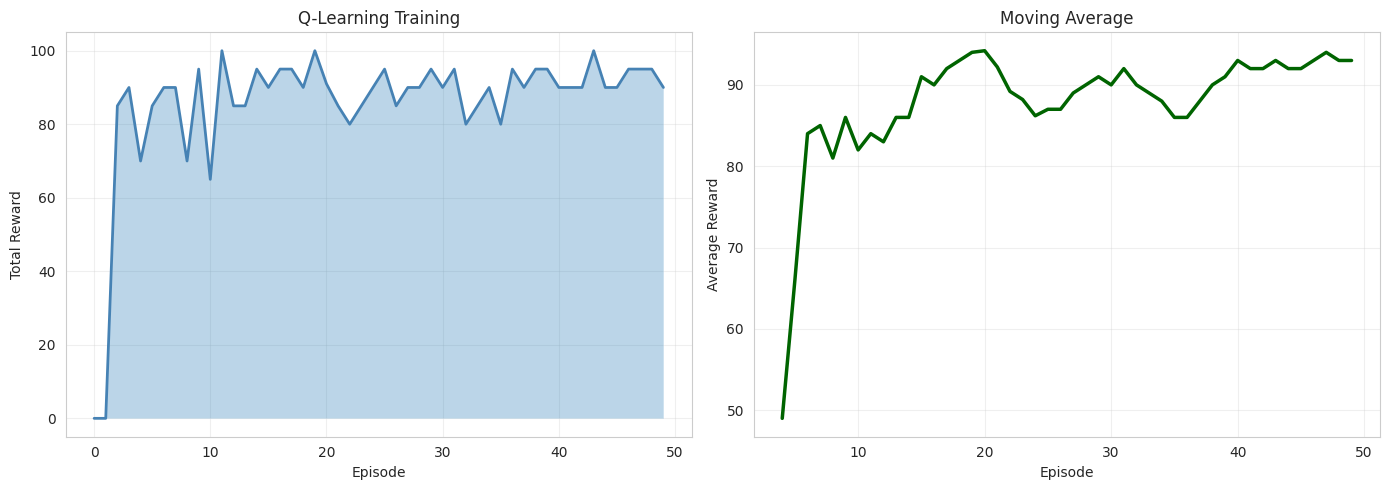


Training Stats:
  Avg Reward (all): 85.62
  Avg Reward (last 10): 92.50


In [67]:
# Plot training progress
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(episode_rewards, linewidth=2, color='steelblue')
axes[0].fill_between(range(len(episode_rewards)), episode_rewards, alpha=0.3)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Q-Learning Training')
axes[0].grid(True, alpha=0.3)

window = 5
moving_avg = pd.Series(episode_rewards).rolling(window=window).mean()
axes[1].plot(moving_avg, linewidth=2.5, color='darkgreen')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Average Reward')
axes[1].set_title('Moving Average')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nTraining Stats:')
print(f'  Avg Reward (all): {np.mean(episode_rewards):.2f}')
print(f'  Avg Reward (last 10): {np.mean(episode_rewards[-10:]):.2f}')

---
## SECTION 5: GENERATE RECOMMENDATIONS
---

In [68]:
# Get KB recommendations
print('='*80)
print(f'KNOWLEDGE-BASED RECOMMENDATIONS (User {test_user_id})')
print('='*80 + '\n')

kb_recs = collaborative_filtering_recommender(
    test_user_id, combined_df, user_movie_matrix, netflix_df,
    movieId_dict, n_similar_users=10, n_recommendations=10
)

for idx, (i, row) in enumerate(kb_recs.iterrows(), 1):
    print(f'{idx:2d}. {row['title'][:50]:50s} | Score: {row['score']:.4f}')
    print(f'    Type: {row['type']} | Genres: {row['listed_in']}')
    print()

KNOWLEDGE-BASED RECOMMENDATIONS (User 190)

 1. Family Reunion                                     | Score: 0.4518
    Type: TV Show | Genres: Kids' TV, TV Comedies

 2. Ms. Mammy                                          | Score: 0.4518
    Type: Movie | Genres: Comedies, International Movies

 3. A StoryBots Christmas                              | Score: 0.4518
    Type: Movie | Genres: Children & Family Movies, Comedies

 4. Love Jones                                         | Score: 0.4518
    Type: Movie | Genres: Comedies, Dramas, Independent Movies

 5. Kongsuni and Friends                               | Score: 0.4267
    Type: TV Show | Genres: Kids' TV, Korean TV Shows

 6. An American Tail: Fievel Goes West                 | Score: 0.4267
    Type: Movie | Genres: Children & Family Movies

 7. My Travel Buddy                                    | Score: 0.4267
    Type: Movie | Genres: Comedies, International Movies

 8. Dead Again in Tombstone                            | Sc

In [69]:
import pandas as pd

# Get RL recommendations
print('\n' + '='*80)
print(f'REINFORCEMENT LEARNING RECOMMENDATIONS (User {test_user_id})')
print('='*80 + '\n')

top_actions = agent.get_top_recommendations(n=10)
rl_recs = []

for rank, action in enumerate(top_actions, 1):
    movie_id = movies_list[action]
    q_value = agent.q_table[action]
    movie_info = netflix_df[netflix_df['show_id'] == movie_id]

    if len(movie_info) > 0:
        title = movie_info.iloc[0]['title']
        movie_type = movie_info.iloc[0]['type']
        genres = movie_info.iloc[0]['listed_in']
    else:
        title = f'Movie {movie_id}'
        movie_type = 'Unknown'
        genres = 'Unknown'

    is_watched = movie_id in user_ratings_dict
    watched_str = '✓ WATCHED' if is_watched else '  NEW'

    rl_recs.append({'movieId': movie_id, 'title': title, 'type': movie_type,
                    'genres': genres, 'q_value': q_value})

    print(f'{rank:2d}. {title[:50]:50s} {watched_str}')
    print(f'    Q-Value: {q_value:.6f}')
    print(f'    Type: {movie_type} | Genres: {genres}')
    print()

rl_recs_df = pd.DataFrame(rl_recs)


REINFORCEMENT LEARNING RECOMMENDATIONS (User 190)

 1. Center Stage                                       ✓ WATCHED
    Q-Value: 1.000000
    Type: Movie | Genres: Dramas

 2. Miss Rose                                            NEW
    Q-Value: 0.009863
    Type: TV Show | Genres: International TV Shows, Romantic TV Shows, TV Comedies

 3. Eli                                                  NEW
    Q-Value: 0.009862
    Type: Movie | Genres: Horror Movies

 4. Wake Up                                              NEW
    Q-Value: 0.009860
    Type: TV Show | Genres: International TV Shows, TV Dramas

 5. Fadily Camara : La plus drôle de tes copines         NEW
    Q-Value: 0.009860
    Type: Movie | Genres: Stand-Up Comedy

 6. Win the Wilderness                                   NEW
    Q-Value: 0.009860
    Type: TV Show | Genres: British TV Shows, International TV Shows, Reality TV

 7. Mud                                                  NEW
    Q-Value: 0.009856
    Type: Movie 

---
## SECTION 6: HYBRID RECOMMENDATIONS
---

In [70]:
print('\n' + '='*80)
print(f'HYBRID RECOMMENDATIONS (40% KB + 60% RL)')
print('='*80 + '\n')

# Normalize scores
kb_max = kb_recs['score'].max()
kb_recs['kb_norm'] = kb_recs['score'] / kb_max

rl_max = rl_recs_df['q_value'].max()
rl_recs_df['rl_norm'] = rl_recs_df['q_value'] / (rl_max + 1e-8)

# Merge recommendations
all_movies = set(kb_recs['movieId'].values) | set(rl_recs_df['movieId'].values)
hybrid_recs = []

for movie_id in all_movies:
    kb_score = kb_recs[kb_recs['movieId'] == movie_id]['kb_norm'].values
    kb_score = kb_score[0] if len(kb_score) > 0 else 0

    rl_score = rl_recs_df[rl_recs_df['movieId'] == movie_id]['rl_norm'].values
    rl_score = rl_score[0] if len(rl_score) > 0 else 0

    hybrid_score = 0.4 * kb_score + 0.6 * rl_score

    movie_info = netflix_df[netflix_df['show_id'] == movie_id]
    title = movie_info.iloc[0]['title'] if len(movie_info) > 0 else f'Movie {movie_id}'

    hybrid_recs.append({
        'movieId': movie_id,
        'title': title,
        'kb_score': kb_score,
        'rl_score': rl_score,
        'hybrid_score': hybrid_score
    })

hybrid_df = pd.DataFrame(hybrid_recs).sort_values('hybrid_score', ascending=False)

for idx, (i, row) in enumerate(hybrid_df.head(10).iterrows(), 1):
    print(f'{idx:2d}. {row['title'][:60]:60s}')
    print(f'    Hybrid: {row['hybrid_score']:.4f} | KB: {row['kb_score']:.4f} | RL: {row['rl_score']:.4f}')
    print()


HYBRID RECOMMENDATIONS (40% KB + 60% RL)

 1. Center Stage                                                
    Hybrid: 0.6000 | KB: 0.0000 | RL: 1.0000

 2. Ms. Mammy                                                   
    Hybrid: 0.4000 | KB: 1.0000 | RL: 0.0000

 3. Love Jones                                                  
    Hybrid: 0.4000 | KB: 1.0000 | RL: 0.0000

 4. Family Reunion                                              
    Hybrid: 0.4000 | KB: 1.0000 | RL: 0.0000

 5. A StoryBots Christmas                                       
    Hybrid: 0.4000 | KB: 1.0000 | RL: 0.0000

 6. Kongsuni and Friends                                        
    Hybrid: 0.3778 | KB: 0.9446 | RL: 0.0000

 7. An American Tail: Fievel Goes West                          
    Hybrid: 0.3778 | KB: 0.9446 | RL: 0.0000

 8. My Travel Buddy                                             
    Hybrid: 0.3778 | KB: 0.9446 | RL: 0.0000

 9. Chennai Express                                             
    

---
## SECTION 7: VISUALIZATION
---

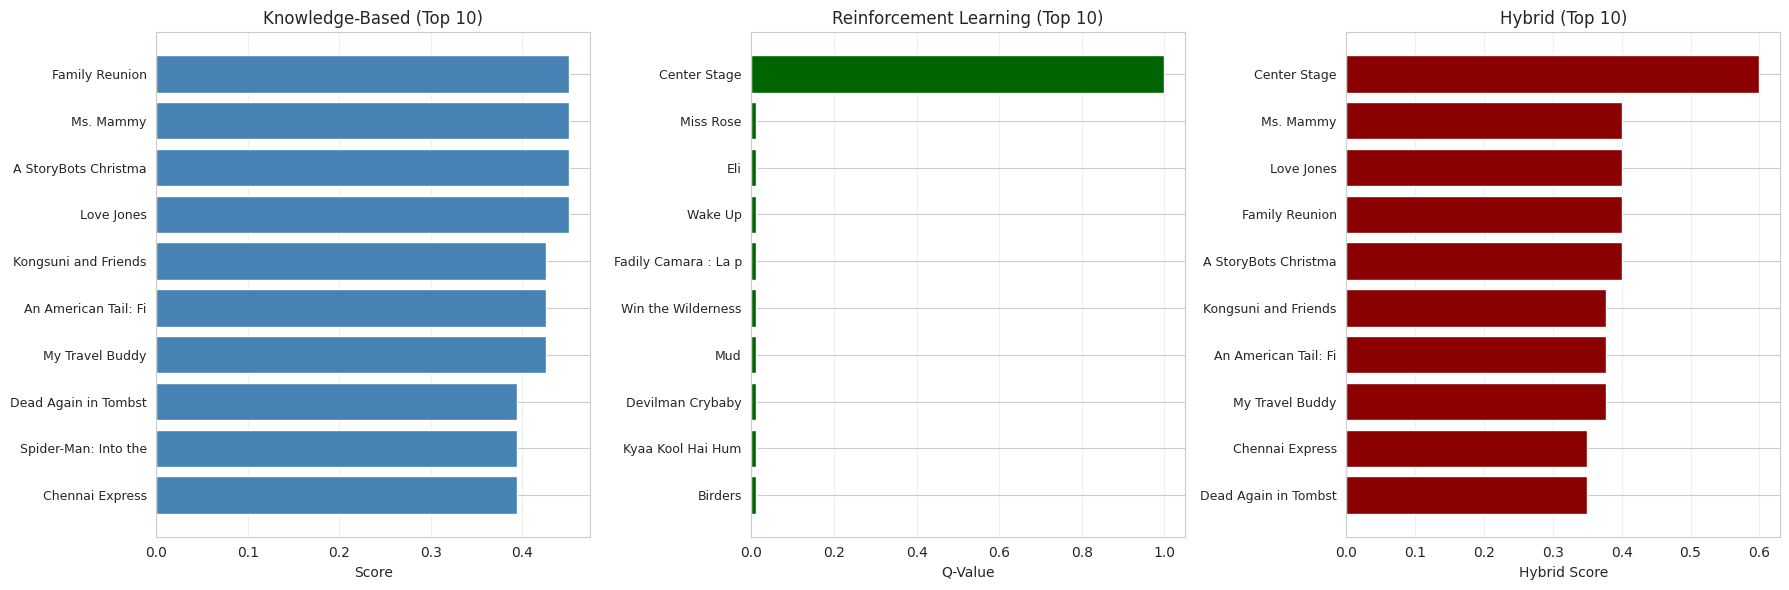

✅ Visualization complete!


In [71]:
# Create comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# KB top 10
kb_top = kb_recs.head(10)
axes[0].barh(range(len(kb_top)), kb_top['score'].values, color='steelblue')
axes[0].set_yticks(range(len(kb_top)))
axes[0].set_yticklabels([t[:20] for t in kb_top['title'].values], fontsize=9)
axes[0].set_xlabel('Score')
axes[0].set_title('Knowledge-Based (Top 10)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# RL top 10
rl_top = rl_recs_df.head(10)
axes[1].barh(range(len(rl_top)), rl_top['q_value'].values, color='darkgreen')
axes[1].set_yticks(range(len(rl_top)))
axes[1].set_yticklabels([t[:20] for t in rl_top['title'].values], fontsize=9)
axes[1].set_xlabel('Q-Value')
axes[1].set_title('Reinforcement Learning (Top 10)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Hybrid top 10
hybrid_top = hybrid_df.head(10)
axes[2].barh(range(len(hybrid_top)), hybrid_top['hybrid_score'].values, color='darkred')
axes[2].set_yticks(range(len(hybrid_top)))
axes[2].set_yticklabels([t[:20] for t in hybrid_top['title'].values], fontsize=9)
axes[2].set_xlabel('Hybrid Score')
axes[2].set_title('Hybrid (Top 10)')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Visualization complete!')

---
## SECTION 8: SUMMARY
---

In [72]:
print('''
╔════════════════════════════════════════════════════════════════════════╗
║      NETFLIX MOVIE RECOMMENDATION SYSTEM - SUMMARY                   ║
╚════════════════════════════════════════════════════════════════════════╝

✅ SYSTEM COMPONENTS:

1. KNOWLEDGE-BASED RECOMMENDER
   - Finds users with similar kaggle kernels output muhammadhananasghar/imdb-movies-content-based-recomendation-system -p /path/to/dest patterns
   - Recommends movies they rated highly
   - Method: Collaborative Filtering + Cosine Similarity

2. REINFORCEMENT LEARNING RECOMMENDER
   - Trains Q-Learning agent on user kaggle kernels output muhammadhananasghar/imdb-movies-content-based-recomendation-system -p /path/to/dests
   - Balances exploration (new movies) vs exploitation (quality)
   - Method: Q-Learning with Epsilon-Greedy Policy

3. HYBRID APPROACH
   - Combines both methods with weighted scores
   - 40% Knowledge-Based + 60% Reinforcement Learning
   - Delivers balanced, high-quality recommendations

🚀 READY FOR USE:
   - Modify test_user_id to any user in the system
   - Adjust KB/RL weights for different use cases
   - Retrain RL agent with new user data

📊 NEXT STEPS:
   - Add content-based filtering (genres, metadata)
   - Implement deep learning models
   - Add user feedback loop
   - Deploy to production
''')


╔════════════════════════════════════════════════════════════════════════╗
║      NETFLIX MOVIE RECOMMENDATION SYSTEM - SUMMARY                   ║
╚════════════════════════════════════════════════════════════════════════╝

✅ SYSTEM COMPONENTS:

1. KNOWLEDGE-BASED RECOMMENDER
   - Finds users with similar kaggle kernels output muhammadhananasghar/imdb-movies-content-based-recomendation-system -p /path/to/dest patterns
   - Recommends movies they rated highly
   - Method: Collaborative Filtering + Cosine Similarity

2. REINFORCEMENT LEARNING RECOMMENDER
   - Trains Q-Learning agent on user kaggle kernels output muhammadhananasghar/imdb-movies-content-based-recomendation-system -p /path/to/dests
   - Balances exploration (new movies) vs exploitation (quality)
   - Method: Q-Learning with Epsilon-Greedy Policy

3. HYBRID APPROACH
   - Combines both methods with weighted scores
   - 40% Knowledge-Based + 60% Reinforcement Learning
   - Delivers balanced, high-quality recommendations

🚀 RE